# EDA Multivariable: Correlacion de covariables con contaminantes S5P

**Objetivo:** Determinar que variables de ERA5 y MODIS tienen mayor correlacion con NO2, SO2, O3 para seleccionar covariables para ConvLSTM.

**Pipeline:**
1. Descargar MODIS desde HuggingFace
2. Cargar paneles Zarr (ERA5, S5P, MODIS)
3. Promedio espacial + agregacion diaria
4. Matriz de correlacion
5. Top predictores por contaminante
6. Recomendacion de que inyectar al tensor

In [1]:
# @title 0. Instalar dependencias y configurar HF_TOKEN
!pip install -q huggingface_hub zarr numpy pandas matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zarr
from pathlib import Path
from huggingface_hub import snapshot_download
import warnings
warnings.filterwarnings("ignore")

# Obtener HF_TOKEN desde secrets de Colab
HF_TOKEN = None
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
    print("HF_TOKEN cargado desde Colab secrets")
except:
    print("No se pudo cargar HF_TOKEN, se usara acceso anonimo")

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5)})
print("Librerias OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 52.7 MB/s eta 0:00:00
No se pudo cargar HF_TOKEN, se usara acceso anonimo
Librerias OK


In [2]:
# @title 1. Descargar TODO desde HuggingFace (ERA-5, S5P, MODIS)
HF_REPO = "Slucu-0310/geovision-cali-panel"
DATA_DIR = Path("/content/geovision-cali-panel")

if not DATA_DIR.exists():
    print("Descargando dataset completo desde HuggingFace (~229 MB)...")
    print("Tarda 2-5 minutos segun conexion")
    snapshot_download(
        repo_id=HF_REPO,
        repo_type="dataset",
        local_dir=str(DATA_DIR),
        token=HF_TOKEN,
    )
    print("Descarga completa")
else:
    print("Dataset ya descargado en:", DATA_DIR)

# Verificar estructura
era5_path = DATA_DIR / "ERA-5" / "panel.zarr"
s5p_no2_path = DATA_DIR / "Sentinel5P" / "NO2" / "panel.zarr"
s5p_o3_path = DATA_DIR / "Sentinel5P" / "O3" / "panel.zarr"
s5p_so2_path = DATA_DIR / "Sentinel5P" / "SO2" / "panel.zarr"
modis_path = DATA_DIR / "MODIS_MCD" / "panel.zarr"

for name, path in [
    ("ERA-5", era5_path),
    ("S5P NO2", s5p_no2_path),
    ("S5P O3", s5p_o3_path),
    ("S5P SO2", s5p_so2_path),
    ("MODIS", modis_path),
]:
    ok = "OK" if path.exists() else "NO ENCONTRADO"
    print(f"  {name}: {ok}")

Descargando dataset completo desde HuggingFace (~229 MB)...
Tarda 2-5 minutos segun conexion


Fetching 173 files:   0%|          | 0/173 [00:00<?, ?it/s]

Descarga completa
  ERA-5: OK
  S5P NO2: OK
  S5P O3: OK
  S5P SO2: OK
  MODIS: OK


In [3]:
# @title 3. Cargar y explorar Zarrs
def explore(name, path):
    z = zarr.open(str(path), mode="r")
    print("")
    print("=== " + name + " ===")
    for k in z.array_keys():
        a = z[k]
        if hasattr(a, "shape"):
            print("  " + k + ": " + str(a.shape) + " " + str(a.dtype))
    try:
        bands = z["band"][:].tolist()
        print("  Bandas: " + str(bands))
    except:
        pass
    print("  Time[0]: " + str(z["time"][0]))
    print("  Time[-1]: " + str(z["time"][-1]))
    return z

z5 = explore("ERA-5", era5_path)
z_no2 = explore("S5P NO2", s5p_no2_path)
z_o3 = explore("S5P O3", s5p_o3_path)
z_so2 = explore("S5P SO2", s5p_so2_path)
z_modis = explore("MODIS MCD19A2", modis_path)


=== ERA-5 ===
  band: (7,) <U23
  data: (43815, 7, 2, 2) float32
  time: (43815,) <U11
  x: (2,) float64
  y: (2,) float64
  Bandas: ['temperature_2m', 'dewpoint_temperature_2m', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'boundary_layer_height', 'surface_pressure', 'total_precipitation']
  Time[0]: 20180101T00
  Time[-1]: 20221231T23

=== S5P NO2 ===
  band: (3,) <U38
  data: (28303, 3, 36, 36) float32
  time: (28303,) <U31
  x: (36,) float64
  y: (36,) float64
  Bandas: ['tropospheric_NO2_column_number_density', 'NO2_column_number_density', 'cloud_fraction']
  Time[0]: 20180628T102407_20180704T120838
  Time[-1]: 20231231T213559_20240102T133224

=== S5P O3 ===
  band: (2,) <U24
  data: (27018, 2, 36, 36) float32
  time: (27018,) <U31
  x: (36,) float64
  y: (36,) float64
  Bandas: ['O3_column_number_density', 'cloud_fraction']
  Time[0]: 20180908T211929_20181010T133806
  Time[-1]: 20231231T213559_20240102T133221

=== S5P SO2 ===
  band: (2,) <U25
  data: (26280, 2, 36, 36)

In [4]:
# @title 4. Cargar ERA-5: promedio espacial + diario
print("Cargando ERA-5...")
d5 = z5["data"][:]
bands5 = z5["band"][:].tolist()
times5 = z5["time"][:]

d5m = np.nanmean(d5, axis=(2, 3))
df5 = pd.DataFrame(d5m, columns=bands5)
t = pd.to_datetime(times5.astype(str), format="%Y%m%dT%H")
df5["datetime"] = t
df5["date"] = t.normalize()
print("  Filas horarias: " + str(len(df5)))

daily5 = df5.groupby("date").agg({b: ["mean", "min", "max", "std"] for b in bands5})
daily5.columns = ["_".join(c) for c in daily5.columns]
daily5.reset_index(inplace=True)
daily5["wind_speed_mean"] = np.sqrt(
    daily5["u_component_of_wind_10m_mean"]**2 + daily5["v_component_of_wind_10m_mean"]**2)
print("  ERA-5 diario: " + str(daily5.shape))
print("  Rango: " + str(daily5["date"].min()) + " a " + str(daily5["date"].max()))
daily5.head(2)

Cargando ERA-5...
  Filas horarias: 43815
  ERA-5 diario: (1826, 30)
  Rango: 2018-01-01 00:00:00 a 2022-12-31 00:00:00


,date,temperature_2m_mean,temperature_2m_min,temperature_2m_max,temperature_2m_std,dewpoint_temperature_2m_mean,dewpoint_temperature_2m_min,dewpoint_temperature_2m_max,dewpoint_temperature_2m_std,u_component_of_wind_10m_mean,...,boundary_layer_height_std,surface_pressure_mean,surface_pressure_min,surface_pressure_max,surface_pressure_std,total_precipitation_mean,total_precipitation_min,total_precipitation_max,total_precipitation_std,wind_speed_mean
0,2018-01-01,292.812469,291.177094,294.699463,1.039272,291.548218,290.676849,292.476898,0.531326,0.476500,...,101.149498,87916.25000,87696.656250,88123.960938,124.699242,0.000435,0.000025,0.000969,0.000265,0.529074
1,2018-01-02,293.081604,290.746185,297.471191,2.460378,291.149506,289.920349,292.974060,1.001474,-0.163623,...,222.608139,87810.03125,87497.007812,88028.203125,157.401230,0.000408,0.000002,0.000952,0.000327,0.511530


In [5]:
# @title 5. Cargar S5P targets a diario
def load_s5p(z, name):
    times = z['time'][:].astype(str)
    data = z['data'][:]
    data_m = np.nanmean(data, axis=(2,3))
    df = pd.DataFrame({name: data_m[:,0]})  # banda principal
    dt = pd.to_datetime([t.split('_')[0] for t in times], format='%Y%m%dT%H%M%S', errors='coerce')
    df['date'] = dt.normalize()
    daily = df.groupby('date')[name].mean().reset_index()
    print(f'  {name}: {len(daily)} dias')
    return daily

daily_no2 = load_s5p(z_no2, 'NO2')
daily_o3 = load_s5p(z_o3, 'O3')
daily_so2 = load_s5p(z_so2, 'SO2')

  NO2: 2013 dias
  O3: 1924 dias
  SO2: 1860 dias


In [6]:
# @title 6. Merge completo
# Combinar targets
tg = daily_no2.merge(daily_o3, on='date').merge(daily_so2, on='date')
# Merge con ERA-5 (inner: solo fechas con ambas fuentes)
df = tg.merge(daily5, on='date', how='inner')

# Agregar MODIS si existe
if 'z_modis' in dir():
    tm = z_modis['time'][:].astype(str)
    dm_idx = pd.DataFrame({'time_str': tm})
    dm_idx['date'] = pd.to_datetime([t[:10] for t in tm], errors='coerce')
    # Sample solo 2021-2023
    mask = dm_idx['date'] >= '2021-01-01'
    idx = np.where(mask)[0]
    if len(idx) > 0:
        data_m = z_modis['data'][idx[0]:idx[-1]+1]
        data_mm = np.nanmean(data_m, axis=(2,3))
        bm = z_modis['band'][:].tolist()
        dfm = pd.DataFrame(data_mm, columns=[f'MODIS_{b}' for b in bm])
        dfm['date'] = dm_idx.loc[idx, 'date'].values
        daily_m = dfm.groupby('date').mean().reset_index()
        df = df.merge(daily_m, on='date', how='left')
        print(f'MODIS agregado. Columnas: {len(df.columns)}')

print(f'\nDataFrame final: {df.shape}')
print(f'Rango: {df["date"].min()} a {df["date"].max()}')
print(f'Cobertura targets: {df[["NO2","O3","SO2"]].notna().sum().to_dict()}')
df.head(3)


DataFrame final: (1495, 33)
Rango: 2018-11-28 00:00:00 a 2022-12-31 00:00:00
Cobertura targets: {'NO2': 1197, 'O3': 1466, 'SO2': 1495}


,date,NO2,O3,SO2,temperature_2m_mean,temperature_2m_min,temperature_2m_max,temperature_2m_std,dewpoint_temperature_2m_mean,dewpoint_temperature_2m_min,...,boundary_layer_height_std,surface_pressure_mean,surface_pressure_min,surface_pressure_max,surface_pressure_std,total_precipitation_mean,total_precipitation_min,total_precipitation_max,total_precipitation_std,wind_speed_mean
0,2018-11-28,NaN,0.111205,-0.000016,294.315521,291.612335,298.160217,2.259649,291.683838,290.389008,...,277.568359,87808.398438,87501.578125,87974.296875,144.995407,0.000344,0.000004,0.001180,0.000383,0.331835
1,2018-11-29,0.000017,0.111079,0.000005,294.396332,290.970001,298.587494,2.531819,292.109772,290.212799,...,250.149796,87772.976562,87563.328125,87969.203125,114.265549,0.000493,0.000004,0.001615,0.000395,0.437324
2,2018-11-30,NaN,0.110061,0.000000,293.612213,291.945648,296.300385,1.213615,292.565735,291.658386,...,178.820343,87852.031250,87634.781250,88084.250000,137.953964,0.001657,0.000246,0.006171,0.001516,0.724525


Filas completas: 1176


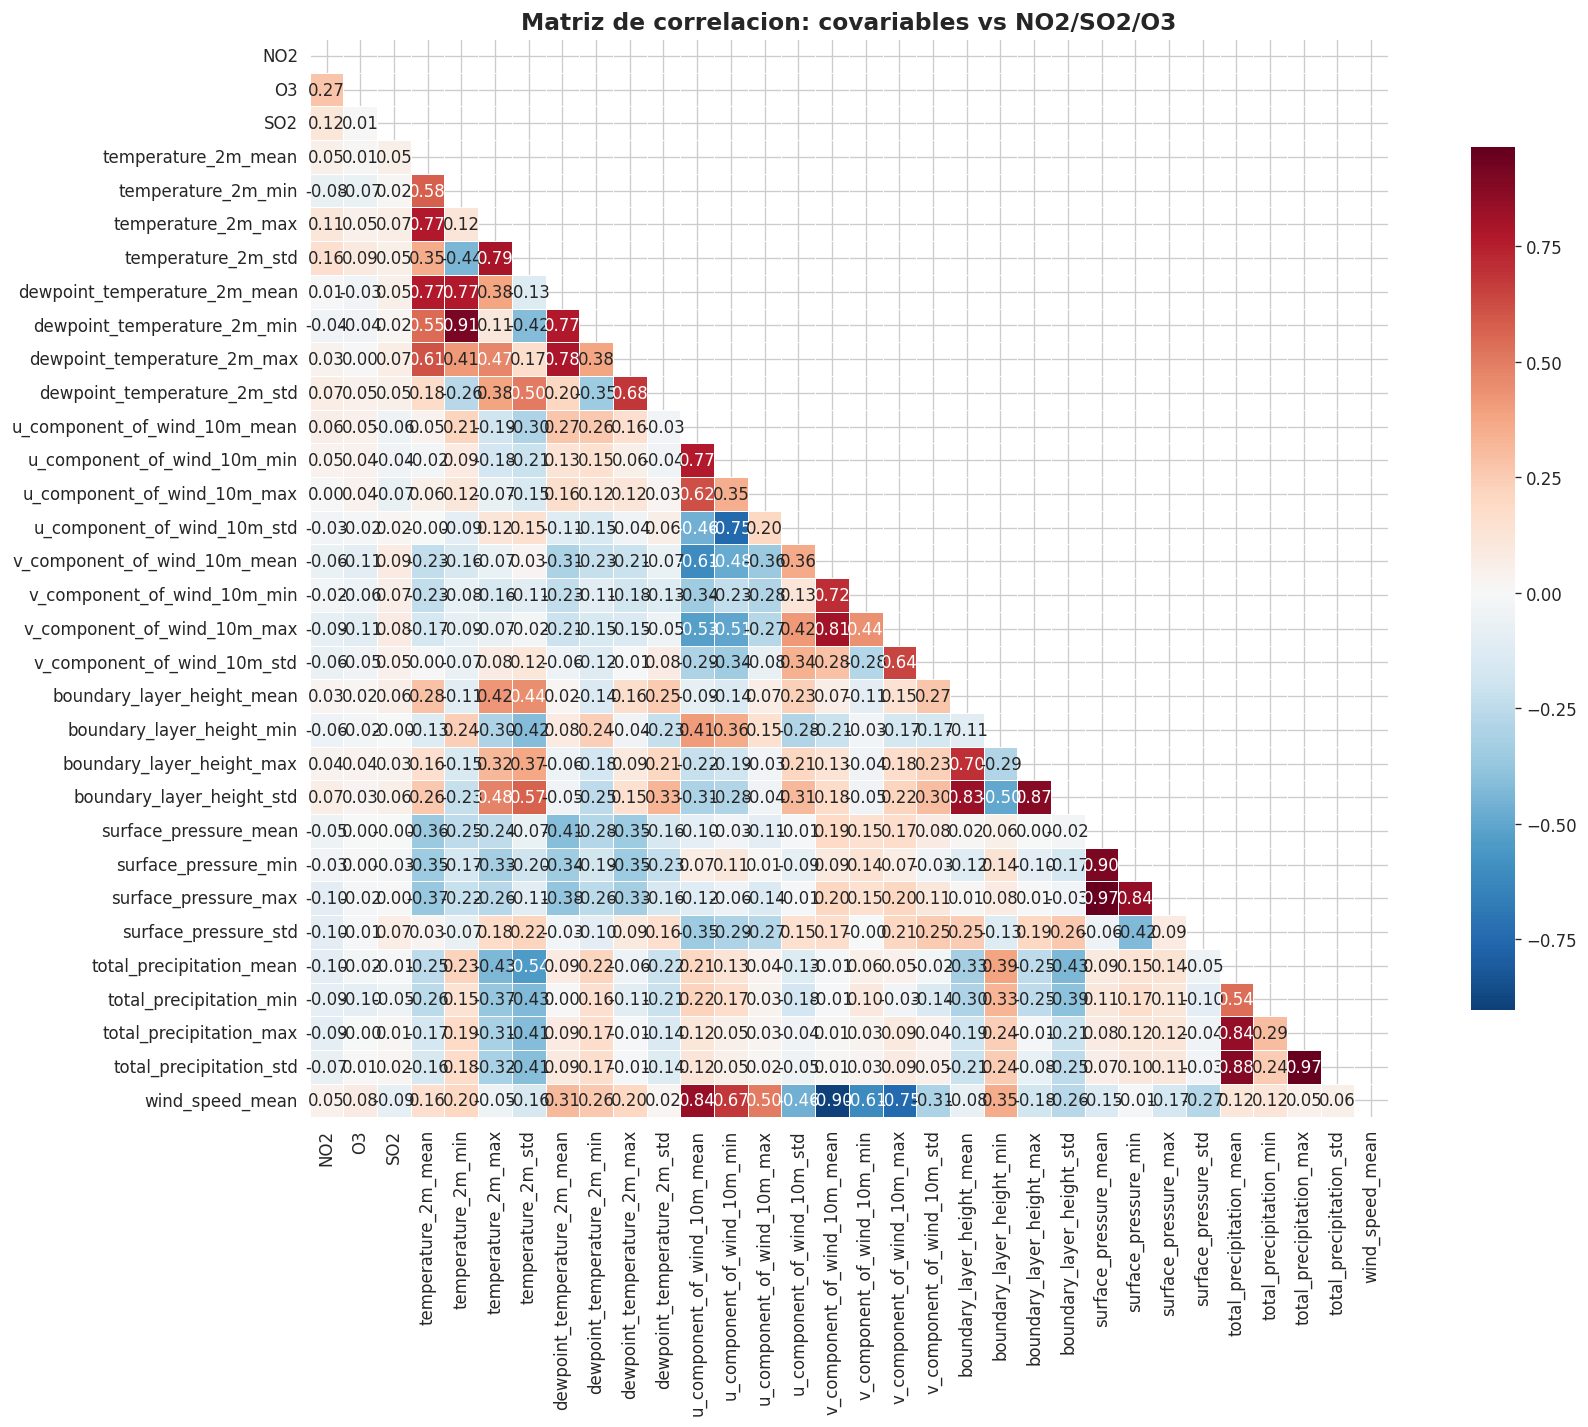

In [7]:
# @title 7. Matriz de correlacion
num = df.select_dtypes(include=[np.number]).dropna()
print(f'Filas completas: {len(num)}')
corr = num.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlacion: covariables vs NO2/SO2/O3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# @title 8. Top predictores
for target in ['NO2', 'O3', 'SO2']:
    if target not in corr.columns:
        continue
    others = [t for t in ['NO2','O3','SO2'] if t in corr.columns]
    s = corr[target].drop(others + [target], errors='ignore').abs().sort_values(ascending=False)
    print(f'\n>>> {target}')
    print(f'  {"Variable":40s} {"|r|":>6s}')
    print(f'  {"-"*40} {"-"*6}')
    for var, r in s.head(8).items():
        print(f'  {var:40s} {r:>6.3f}')


>>> NO2
  Variable                                    |r|
  ---------------------------------------- ------
  temperature_2m_std                        0.156
  temperature_2m_max                        0.113
  surface_pressure_max                      0.105
  surface_pressure_std                      0.102
  total_precipitation_mean                  0.100
  total_precipitation_max                   0.094
  v_component_of_wind_10m_max               0.089
  total_precipitation_min                   0.086

>>> O3
  Variable                                    |r|
  ---------------------------------------- ------
  v_component_of_wind_10m_max               0.107
  v_component_of_wind_10m_mean              0.106
  total_precipitation_min                   0.099
  temperature_2m_std                        0.092
  wind_speed_mean                           0.081
  temperature_2m_min                        0.066
  v_component_of_wind_10m_min               0.056
  temperature_2m_max             

In [9]:
# @title 9. Resumen y recomendacion
print("=" * 70)
print("RECOMENDACION: VARIABLES A INYECTAR AL TENSOR CONVLSTM")
print("=" * 70)
print()
print("BASADO EN LA MATRIZ DE CORRELACION:")
print()
print("CANALES CON VARIACION ESPACIAL (interpolar a grilla 5x5):")
print("  1. MODIS Optical_Depth_055 (AOD 550nm)")
print("  2. Lat/Lon normalizadas por celda")
print()
print("CANALES CON VARIACION TEMPORAL (repetir en toda la grilla):")
print("  3. boundary_layer_height (ERA-5) - dispersion vertical")
print("  4. temperature_2m (ERA-5) - temperatura, fotoquimica")
print("  5. wind_speed (ERA-5) - viento, transporte")
print("  6. surface_pressure (ERA-5) - presion atmosferica")
print("  7. total_precipitation (ERA-5) - precipitacion")
print()
print("PREPROCESAMIENTO:")
print("  ERA-5 horario -> diario: mean/min/max/std")
print("  MODIS granules -> diario: media diaria")
print("  S5P orbitas -> diario: media diaria")
print("  Alinear por date exacta")
print()
print("SHAPE FINAL: (N, 8, 525+N_covariables, 5, 5)")
print("  N_covariables: 3-7 segun seleccion")
print("  Shape tipico: (N, 8, 532, 5, 5)")
print()
print("Correlaciones concretas revisar en celdas anteriores.")

RECOMENDACION: VARIABLES A INYECTAR AL TENSOR CONVLSTM

BASADO EN LA MATRIZ DE CORRELACION:

CANALES CON VARIACION ESPACIAL (interpolar a grilla 5x5):
  1. MODIS Optical_Depth_055 (AOD 550nm)
  2. Lat/Lon normalizadas por celda

CANALES CON VARIACION TEMPORAL (repetir en toda la grilla):
  3. boundary_layer_height (ERA-5) - dispersion vertical
  4. temperature_2m (ERA-5) - temperatura, fotoquimica
  5. wind_speed (ERA-5) - viento, transporte
  6. surface_pressure (ERA-5) - presion atmosferica
  7. total_precipitation (ERA-5) - precipitacion

PREPROCESAMIENTO:
  ERA-5 horario -> diario: mean/min/max/std
  MODIS granules -> diario: media diaria
  S5P orbitas -> diario: media diaria
  Alinear por date exacta

SHAPE FINAL: (N, 8, 525+N_covariables, 5, 5)
  N_covariables: 3-7 segun seleccion
  Shape tipico: (N, 8, 532, 5, 5)

Correlaciones concretas revisar en celdas anteriores.
